
Training RNN model...

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 101ms/step - accuracy: 0.7702 - loss: 0.4763 - val_accuracy: 0.6616 - val_loss: 0.7865
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 101ms/step - accuracy: 0.8609 - loss: 0.3293 - val_accuracy: 0.8432 - val_loss: 0.3921
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 97ms/step - accuracy: 0.9416 - loss: 0.1618 - val_accuracy: 0.7830 - val_loss: 0.5315
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7814 - loss: 0.5337
RNN Test Accuracy: 0.7814

Training LSTM model...

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 87s 271ms/step - accuracy: 0.8005 - loss: 0.4275 - val_accuracy: 0.8720 - val_loss: 0.3069
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 285ms/step - accuracy: 0.9075 - loss: 0.2387 - val_accuracy: 0.8598 - val_loss: 0.3147
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 138s 273ms/step - accuracy: 0.9352 - loss: 0.1713 - val_accuracy: 0.8564 - val_loss: 0.3391
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.8513 - loss

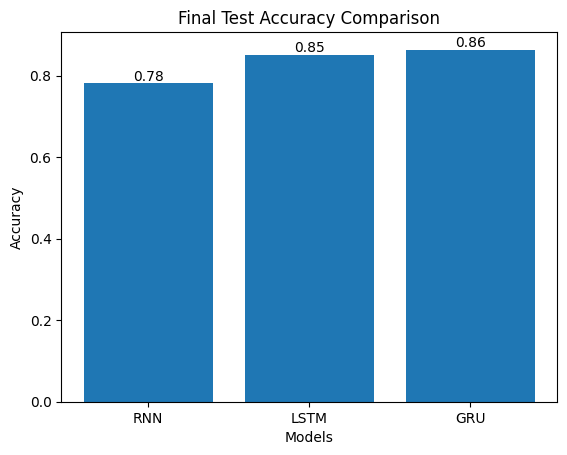

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load dataset
vocab_size = 10000
maxlen = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

def build_model(layer_type):
    model = Sequential()
    model.add(Embedding(vocab_size, 128, input_length=maxlen))

    if layer_type == "RNN":
        model.add(SimpleRNN(64))
    elif layer_type == "LSTM":
        model.add(LSTM(64))
    elif layer_type == "GRU":
        model.add(GRU(64))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

models = ["RNN", "LSTM", "GRU"]

final_acc = []

for m in models:
    print(f"\nTraining {m} model...\n")
    model = build_model(m)

    model.fit(
        x_train, y_train,
        epochs=3,
        batch_size=64,
        validation_split=0.2
    )

    loss, acc = model.evaluate(x_test, y_test)
    final_acc.append(acc)

    print(f"{m} Test Accuracy: {acc:.4f}")

# 🔥 Only Bar Chart
plt.figure()
plt.bar(models, final_acc)

plt.title("Final Test Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i, v in enumerate(final_acc):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.show()